In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
torch.set_default_dtype(torch.float64)

def set_BCs(T):
    T[0]  = T[2]                                  # Left boundary (2 ghost points)
    T[-1] = T[-2]**2 / max(T[-3].item(), 1e-40)  # Right boundary


In [2]:
from scipy.interpolate import CubicSpline

def solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz, tf, n_t_out, device):
    """
    Solve two-layer heat equation from t=0 to t=tf.

    Internally marches at the CFL-stable dt; outputs are resampled
    to n_t_out equally-spaced coarse times via cubic spline in time.

    Parameters
    ----------
    n_t_out : int
        Number of output time points (coarse grid), spanning (0, tf].
    """
    dz = Lz / nz
    z  = torch.arange(-1, nz + 2, device=device) * dz   # (nz+3,)

    m = torch.searchsorted(z, z_dis - 0.5*dz, right=True).item()
    print(f'Interface alignment error: {z[m].item() - z_dis:.2e}')

    k_iL = 8*k1*k2 / (k1 + 7*k2)
    k_iR = 8*k1*k2 / (7*k1 + k2)
    kh = torch.where(z[:-1] < z_dis - 0.5*dz,
                     torch.tensor(k1, device=device),
                     torch.tensor(k2, device=device))   # (nz+2,)
    kh[m-1] = k_iL
    kh[m]   = k_iR

    # --- stability timestep for the whole interval [0, tf] ---
    dt_stab = 0.5 * (dz**2) / max(k1, k2)
    n_fine  = int(np.ceil(tf / dt_stab))
    dt      = tf / n_fine
    print(f'n_fine={n_fine}, dt={dt:.4e}, tf={tf}')

    source    = Pda * torch.exp(-z[1:-1])
    source[0] = Pda * torch.exp(-z[2] / 4)

    T  = torch.zeros(nz + 3, device=device)
    Jh = torch.zeros(nz + 2, device=device)

    # --- decide which fine steps to buffer for the spline ---
    # We keep every stride-th fine step so that the spline is
    # well-conditioned but memory stays modest.
    stride = max(1, n_fine // (10 * n_t_out))
    buf_steps = list(range(stride - 1, n_fine, stride))  # 0-indexed
    if (n_fine - 1) not in buf_steps:
        buf_steps.append(n_fine - 1)

    buf_U = []     # list of (nz+1,) tensors (on CPU to save VRAM)
    buf_t = []     # corresponding fine times

    for step in range(n_fine):
        set_BCs(T)
        Jh = -kh * (T[1:] - T[:-1]) / dz
        T[1:-1] = T[1:-1] + dt / dz * (Jh[:-1] - Jh[1:]) + dt * source

        if step in buf_steps:
            buf_U.append(T[1:-1].cpu().clone())
            buf_t.append((step + 1) * dt)

    set_BCs(T)
    T[m] = T[m] + (2*T[m] - T[m-1] - T[m+1]) / 6

    # --- cubic spline in time, evaluate at coarse output times ---
    t_fine_buf = np.array(buf_t)                           # (n_buf,)
    U_fine_buf = torch.stack(buf_U, dim=1).numpy()         # (nz+1, n_buf)

    t_coarse = np.linspace(tf / n_t_out, tf, n_t_out)     # (n_t_out,)

    cs = CubicSpline(t_fine_buf, U_fine_buf, axis=1, bc_type='not-a-knot')
    U_coarse = torch.from_numpy(cs(t_coarse)).to(device)  # (nz+1, n_t_out)

    t_out = torch.tensor(t_coarse, device=device)
    return z[1:-1], t_out, U_coarse


In [3]:
def smooth_U(U, z, z_dis, k1, k2):
    """
    Smooths the kink at z_dis:
        z >= z_dis : U(z, t)                                (unchanged)
        z <  z_dis : U(z_dis, t) + alpha*(U(z,t) - U(z_dis, t))
    where alpha = k1/k2
    """
    alpha = k1 / k2
    m = torch.searchsorted(z, torch.tensor(z_dis, device=z.device)).item()

    U_smooth = U.clone()
    U_zd = U[m, :]                                         # (n_sub_t,)
    U_smooth[:m, :] = U_zd + alpha * (U[:m, :] - U_zd)

    return U_smooth


## Run the solver

In [8]:
device = 'cuda'
%run func_defs.ipynb
k1 = 1.0; k2 = 2.0; z_dis = 1.0; Pda = 1.0; tf = 2.0
Lz = 8.0; nz_unit = 10; nz = int(Lz) * nz_unit

# Number of coarse output time points (full [0, tf] range, much sparser than dt_stab)
n_t_out = 81

z, t_out, U = solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz, tf, n_t_out, device)
U_smooth = smooth_U(U, z, z_dis, k1, k2)
print(f'U shape: {U.shape}')
print(f'U_smooth shape: {U_smooth.shape}')
print(f't_out: {t_out}')


Interface alignment error: 0.00e+00
n_fine=800, dt=2.5000e-03, tf=2.0
U shape: torch.Size([81, 81])
U_smooth shape: torch.Size([81, 81])
t_out: tensor([0.0247, 0.0494, 0.0741, 0.0988, 0.1235, 0.1481, 0.1728, 0.1975, 0.2222,
        0.2469, 0.2716, 0.2963, 0.3210, 0.3457, 0.3704, 0.3951, 0.4198, 0.4444,
        0.4691, 0.4938, 0.5185, 0.5432, 0.5679, 0.5926, 0.6173, 0.6420, 0.6667,
        0.6914, 0.7160, 0.7407, 0.7654, 0.7901, 0.8148, 0.8395, 0.8642, 0.8889,
        0.9136, 0.9383, 0.9630, 0.9877, 1.0123, 1.0370, 1.0617, 1.0864, 1.1111,
        1.1358, 1.1605, 1.1852, 1.2099, 1.2346, 1.2593, 1.2840, 1.3086, 1.3333,
        1.3580, 1.3827, 1.4074, 1.4321, 1.4568, 1.4815, 1.5062, 1.5309, 1.5556,
        1.5802, 1.6049, 1.6296, 1.6543, 1.6790, 1.7037, 1.7284, 1.7531, 1.7778,
        1.8025, 1.8272, 1.8519, 1.8765, 1.9012, 1.9259, 1.9506, 1.9753, 2.0000],
       device='cuda:0')


In [9]:
# Prep to change to s and tau 
zt_grid = torch.cartesian_prod(z, t_out)
zz = zt_grid[:, 0]; tt = zt_grid[:, 1]
ss,ttau = z_t_to_s_tau(zz, tt)
stau = torch.column_stack(z_t_to_s_tau(zz, tt))
W = U_smooth/t_out
W = W.reshape(-1,1)


kratio = torch.ones(len(stau[:,1]),device=device)*(k1/k2)
z_disv = torch.ones(len(stau[:,1]),device=device)*z_dis

out_file = f'./data/2layer_k1{k1}_k2{k2}_nz{nz}.pt'

In [10]:
print(t_out)

tensor([0.0247, 0.0494, 0.0741, 0.0988, 0.1235, 0.1481, 0.1728, 0.1975, 0.2222,
        0.2469, 0.2716, 0.2963, 0.3210, 0.3457, 0.3704, 0.3951, 0.4198, 0.4444,
        0.4691, 0.4938, 0.5185, 0.5432, 0.5679, 0.5926, 0.6173, 0.6420, 0.6667,
        0.6914, 0.7160, 0.7407, 0.7654, 0.7901, 0.8148, 0.8395, 0.8642, 0.8889,
        0.9136, 0.9383, 0.9630, 0.9877, 1.0123, 1.0370, 1.0617, 1.0864, 1.1111,
        1.1358, 1.1605, 1.1852, 1.2099, 1.2346, 1.2593, 1.2840, 1.3086, 1.3333,
        1.3580, 1.3827, 1.4074, 1.4321, 1.4568, 1.4815, 1.5062, 1.5309, 1.5556,
        1.5802, 1.6049, 1.6296, 1.6543, 1.6790, 1.7037, 1.7284, 1.7531, 1.7778,
        1.8025, 1.8272, 1.8519, 1.8765, 1.9012, 1.9259, 1.9506, 1.9753, 2.0000],
       device='cuda:0')


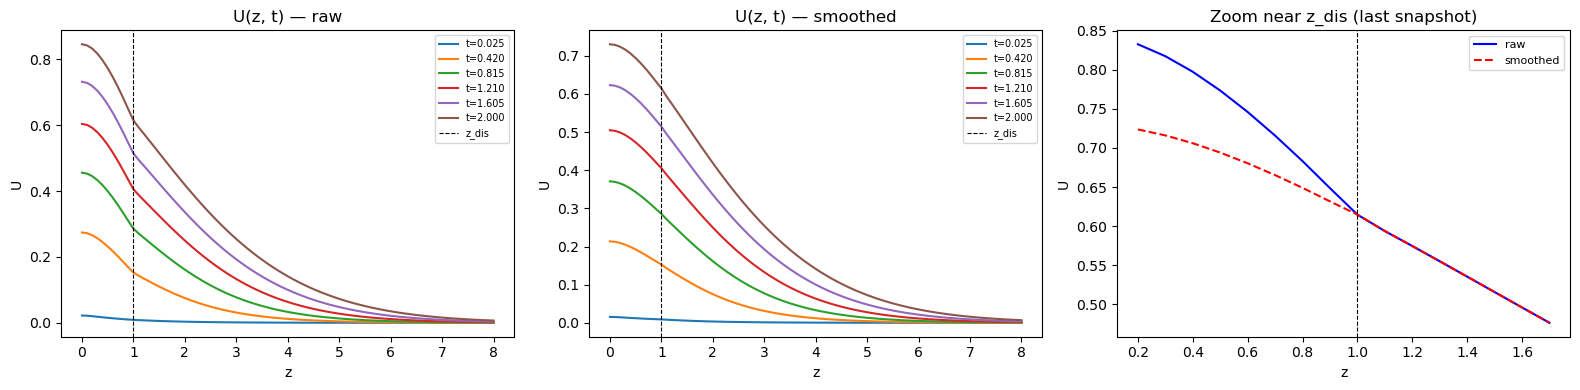

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

z_cpu  = z.cpu(); t_cpu = t_out.cpu()
U_cpu  = U.cpu(); Us_cpu = U_smooth.cpu()
idx    = torch.linspace(0, U_cpu.shape[1]-1, 6).long()
nz     = z.shape[0] - 1
m      = torch.searchsorted(z_cpu, torch.tensor(z_dis)).item()

# U(z) raw
ax = axes[0]
for i in idx:
    ax.plot(z_cpu.numpy(), U_cpu[:, i].numpy(), label=f't={t_cpu[i]:.3f}')
ax.axvline(z_dis, color='k', linestyle='--', linewidth=0.8, label='z_dis')
ax.set_xlabel('z'); ax.set_ylabel('U')
ax.set_title('U(z, t) — raw')
ax.legend(fontsize=7)

# U_smooth(z)
ax = axes[1]
for i in idx:
    ax.plot(z_cpu.numpy(), Us_cpu[:, i].numpy(), label=f't={t_cpu[i]:.3f}')
ax.axvline(z_dis, color='k', linestyle='--', linewidth=0.8, label='z_dis')
ax.set_xlabel('z'); ax.set_ylabel('U')
ax.set_title('U(z, t) — smoothed')
ax.legend(fontsize=7)

# zoom near interface, last snapshot
ax = axes[2]
i_last = U_cpu.shape[1] - 1
w = max(1, nz // 10)
ax.plot(z_cpu[m-w:m+w].numpy(), U_cpu[m-w:m+w, i_last].numpy(), 'b-', label='raw')
ax.plot(z_cpu[m-w:m+w].numpy(), Us_cpu[m-w:m+w, i_last].numpy(), 'r--', label='smoothed')
ax.axvline(z_dis, color='k', linestyle='--', linewidth=0.8)
ax.set_xlabel('z'); ax.set_ylabel('U')
ax.set_title('Zoom near z_dis (last snapshot)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Save dataset

In [12]:
data_to_save = {
        't': tt,
        'z': zz,
        'kratio':  kratio,
        'zdis': z_disv,
        'stau': stau,
        'W': W
    }
torch.save(data_to_save, out_file)
print(f'Data saved in {out_file}')


Data saved in ./data/2layer_k11.0_k22.0_nz80.pt
